In [5]:
import ao_core as ao
import time
import numpy as np
import json
import matplotlib.pyplot as plt

In [2]:
start_time = time.time()
neurons_x = 15 # Number of neurons in the x direction (global variable)
neurons_y = 15  # Number of neurons in the y direction
description = "ARC-AGI architecture" 
arch_i = [4 for x in range(neurons_x * neurons_y)]  # Input architecture (4 neuron per channel for encoding colors in binary) 
arch_z = [4 for x in range(neurons_x * neurons_y)]  # Output architecture 
arch_c = []  
connector_function = "nearest_neighbour_conn"

Z2I_connections = True #wether want Z to I connection or not. If not specified, by default it's False. 
connector_parameters = [4, 4, neurons_x, neurons_y, Z2I_connections]  #ax, dg, neurons_x, neurons_y and Z2I connection (True or default False)


arch = ao.Arch(arch_i, arch_z, arch_c, connector_function, connector_parameters, description)
agent = ao.Agent(arch, save_meta=True)

elapsed_time = time.time() - start_time
print(elapsed_time)

9.517910480499268


In [3]:
times = []

i = 1
while i < 100:
    print(i)
    start_time = time.time()
    agent.next_state(INPUT=np.random.randint(0, 2, size=900), LABEL=np.random.randint(0, 2, size=900), DD=False)
    elapsed_time = time.time() - start_time
    print(elapsed_time)
    times.append(elapsed_time)
    i += 1

with open("next_state_main.json", "w") as f:
    json.dump(times, f)


1
1.0089304447174072
2
0.9877362251281738
3
0.9634373188018799
4
0.9816880226135254
5
1.001490831375122
6
1.0467078685760498
7
1.0306434631347656
8
1.0050239562988281
9
1.0096426010131836
10
1.0563902854919434
11
1.0566761493682861
12
1.0641701221466064
13
1.0399949550628662
14
1.0630667209625244
15
1.0655500888824463
16
1.090848445892334
17
1.0756034851074219
18
1.0514090061187744
19
1.0665569305419922
20
1.0844476222991943
21
1.1111512184143066
22
1.0985298156738281
23
1.0987508296966553
24
1.1028764247894287
25
1.11494779586792
26
1.1193115711212158
27
1.1168568134307861
28
1.1292564868927002
29
1.1403236389160156
30
1.1420762538909912
31
1.1391851902008057
32
1.155837059020996
33
1.1546671390533447
34
1.1677265167236328
35
1.1639196872711182
36
1.1818313598632812
37
1.175771713256836
38
1.1809539794921875
39
1.2132532596588135
40
1.209338903427124
41
1.2096755504608154
42
1.2218878269195557
43
1.2238950729370117
44
1.2330963611602783
45
1.239241361618042
46
1.2483062744140625
47
1.

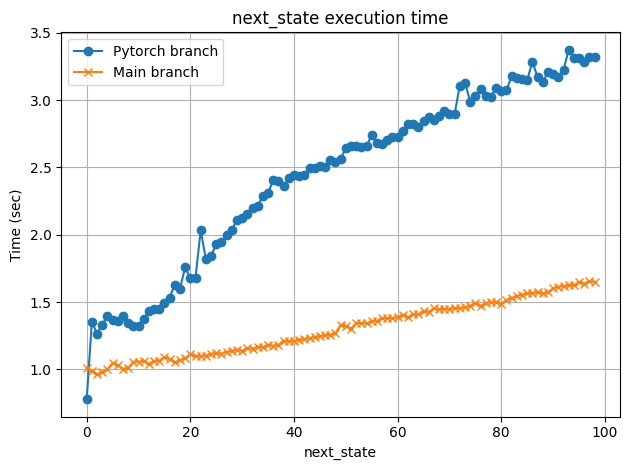

In [8]:
with open("next_state_torch.json") as f:
    torch_times = json.load(f)

with open("next_state_main.json") as f:
    main_times = json.load(f)

# Plot
plt.plot(torch_times, label='Pytorch branch', marker='o')
plt.plot(main_times, label='Main branch', marker='x')
plt.xlabel('next_state')
plt.ylabel('Time (sec)')
plt.title('next_state execution time')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()